In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ankitayadav2005/tesla-dataset/tesla_deliveries_dataset_2015_2025.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/kaggle/input/datasets/ankitayadav2005/tesla-dataset/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

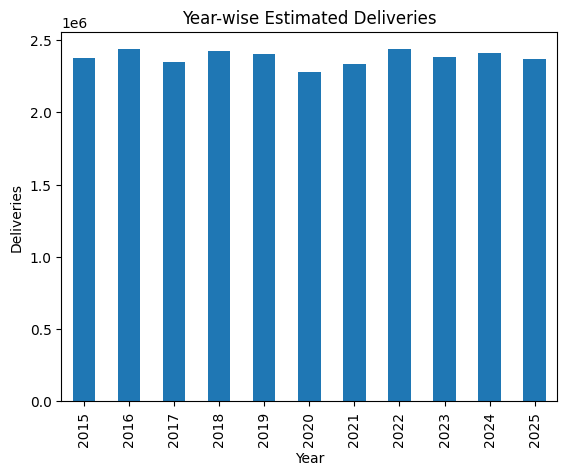

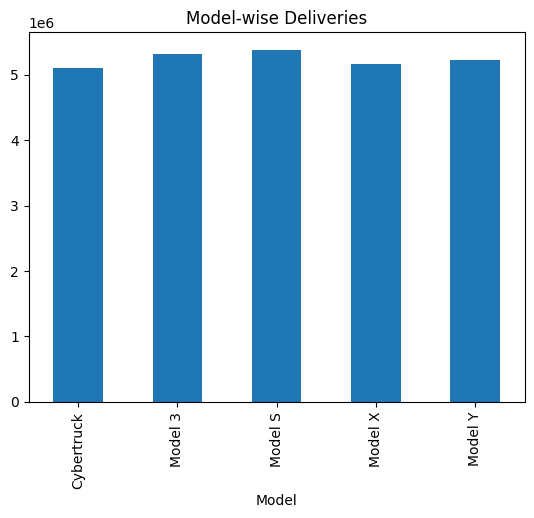

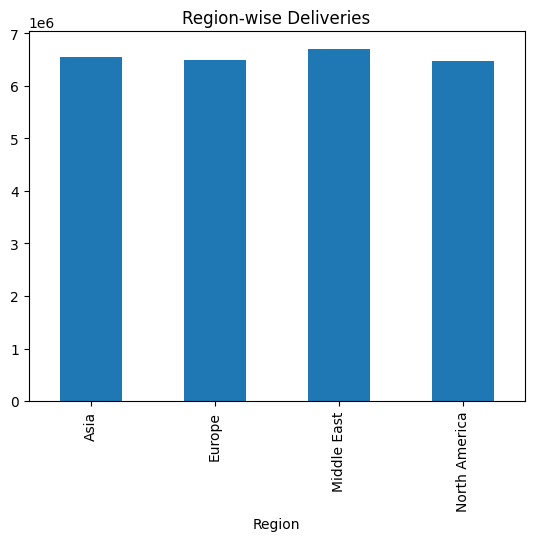

In [5]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")

df.groupby("Year")["Estimated_Deliveries"].sum().plot(kind="bar")
plt.title("Year-wise Estimated Deliveries")
plt.xlabel("Year")
plt.ylabel("Deliveries")
plt.show()

df.groupby("Model")["Estimated_Deliveries"].sum().plot(kind="bar")
plt.title("Model-wise Deliveries")
plt.show()

df.groupby("Region")["Estimated_Deliveries"].sum().plot(kind="bar")
plt.title("Region-wise Deliveries")
plt.show()

In [6]:
df["Quarter"] = ((df["Month"] - 1) // 3) + 1
df["Price_per_kWh"] = df["Avg_Price_USD"] / df["Battery_Capacity_kWh"]
df["Production_Delivery_Ratio"] = df["Production_Units"] / df["Estimated_Deliveries"]
df["Year_Month"] = df["Year"] * 12 + df["Month"]

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Price_per_kWh,Production_Delivery_Ratio,Year_Month
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2,773.952250,1.015641,24281
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,1,829.408667,1.096655,24182
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,1,1437.650244,1.092498,24229
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,744.124250,1.115332,24254
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,957.056500,1.093987,24204


In [7]:
X = df.drop(columns=["Estimated_Deliveries", "Date"])
y = df["Estimated_Deliveries"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 67.99094696969695
RMSE: 113.66497125557332
R2 Score: 0.99913327009551


In [8]:
param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 10, 20],
    "regressor__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Tuned MAE:", mean_absolute_error(y_test, y_pred_best))
print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("Tuned R2:", r2_score(y_test, y_pred_best))

Best Parameters: {'regressor__max_depth': None, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best CV Score: 0.998014263830861
Tuned MAE: 67.23585227272724
Tuned RMSE: 112.086676061312
Tuned R2: 0.9991571729435469


In [9]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_best
})

result.head(20)

,Actual,Predicted
0,6991,7030.975
1,9326,9400.510
2,9061,9097.300
3,8951,8983.300
4,8707,8673.180
5,11351,11384.540
6,14193,14188.510
7,15156,15133.290
8,9915,9978.690
9,7642,7644.065


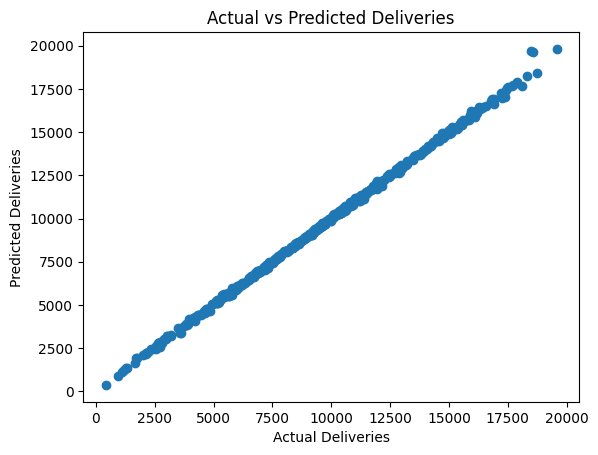

In [10]:
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")
plt.show()

In [11]:
monthly = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()
monthly = monthly.sort_values("Date")

monthly.head()

,Date,Estimated_Deliveries
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


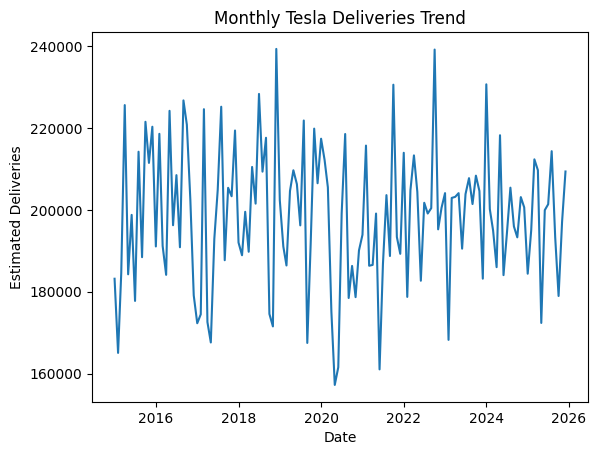

In [12]:
plt.plot(monthly["Date"], monthly["Estimated_Deliveries"])
plt.title("Monthly Tesla Deliveries Trend")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

In [15]:
monthly["Time_Index"] = np.arange(len(monthly))

X_ts = monthly[["Time_Index"]]
y_ts = monthly["Estimated_Deliveries"]

ts_model = LinearRegression()
ts_model.fit(X_ts, y_ts)

future_index = np.arange(len(monthly), len(monthly) + 12).reshape(-1, 1)
future_index_df = pd.DataFrame(future_index, columns=["Time_Index"])
future_pred = ts_model.predict(future_index_df)

future_dates = pd.date_range(
    start=monthly["Date"].max() + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Deliveries": future_pred
})

forecast_df

,Date,Forecasted_Deliveries
0,2026-01-01,198436.571015
1,2026-02-01,198436.459415
2,2026-03-01,198436.347815
3,2026-04-01,198436.236215
4,2026-05-01,198436.124615
5,2026-06-01,198436.013015
6,2026-07-01,198435.901415
7,2026-08-01,198435.789815
8,2026-09-01,198435.678214
9,2026-10-01,198435.566614


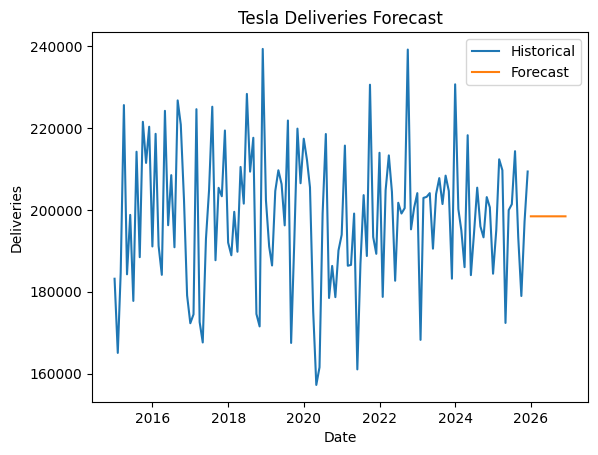

In [14]:
plt.plot(monthly["Date"], monthly["Estimated_Deliveries"], label="Historical")
plt.plot(forecast_df["Date"], forecast_df["Forecasted_Deliveries"], label="Forecast")
plt.title("Tesla Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.show()

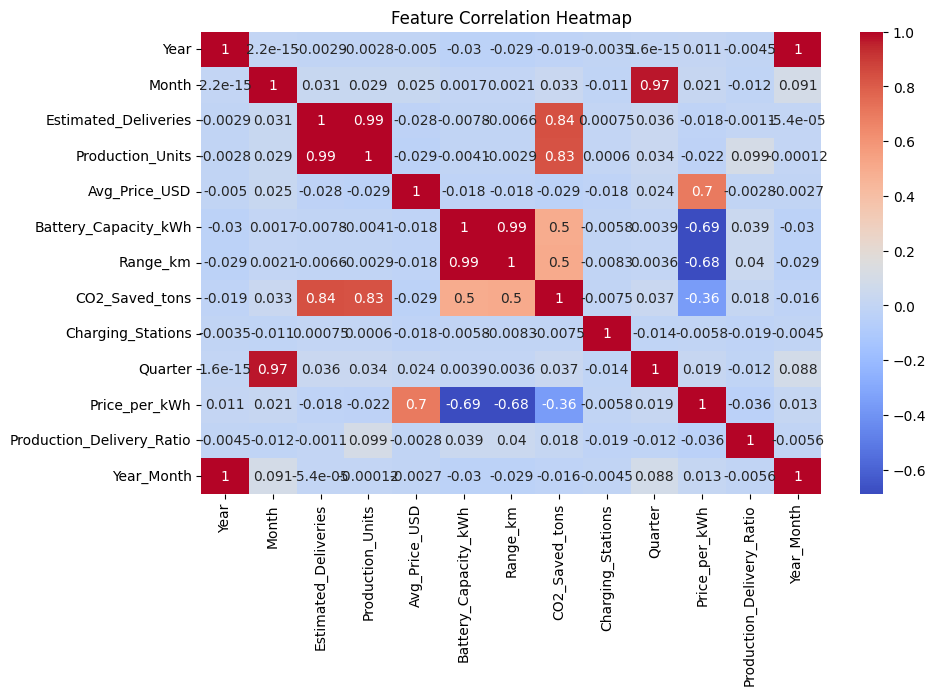

In [16]:
import seaborn as sns

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [17]:
lr = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Random Forest R2:", r2_score(y_test, y_pred_best))

Linear Regression R2: 0.9984036104022491
Random Forest R2: 0.9991571729435469


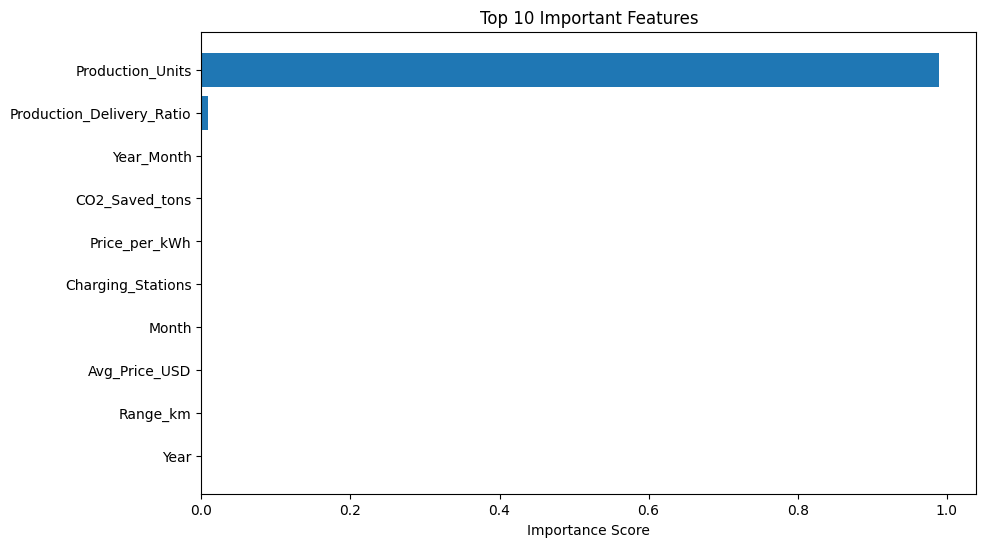

In [18]:
rf_model = best_model.named_steps["regressor"]

feature_names = (
    num_cols.tolist() +
    list(best_model.named_steps["preprocessor"]
         .transformers_[1][1]
         .get_feature_names_out(cat_cols))
)

importance = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"][:10], feat_imp["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

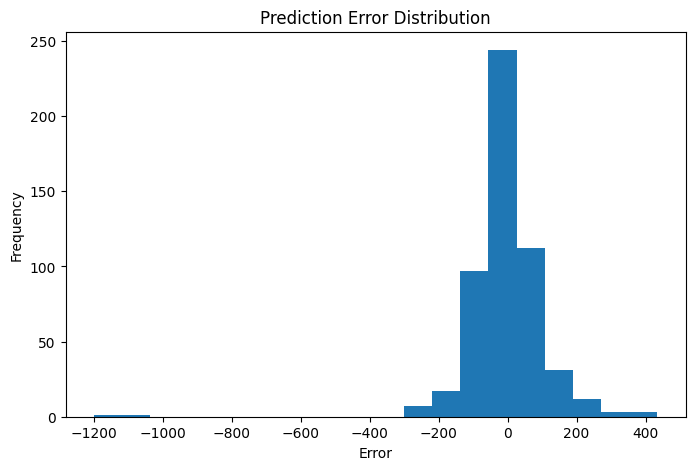

In [19]:
errors = y_test - y_pred_best

plt.figure(figsize=(8,5))
plt.hist(errors, bins=20)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [20]:
summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Value": [
        mean_absolute_error(y_test, y_pred_best),
        np.sqrt(mean_squared_error(y_test, y_pred_best)),
        r2_score(y_test, y_pred_best)
    ]
})

summary

,Metric,Value
0,MAE,67.235852
1,RMSE,112.086676
2,R2 Score,0.999157
